In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv("Dataset/academic_meals_elementary_district.csv")

OUTCOMES = ["ELA_Proficiency", "Math_Proficiency", "Science_Proficiency"]

SES_VARS = [
    "student_low_income_percent",
    "student_disabilities_percent",
    "ROE",
]

HEI_VARS = [
    c for c in df.columns
    if str(c).startswith("HEI 2015") and "Total Score" not in str(c)
]

PREDICTORS = [c for c in SES_VARS + HEI_VARS if c in df.columns]

In [67]:
#helper for handling outliers
class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1

        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        return X_df.clip(self.lower_, self.upper_, axis=1).values

In [68]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def prepare_xy(df, outcome, predictors):
    tmp = df[[outcome] + predictors].copy()
    tmp = tmp.apply(pd.to_numeric, errors="coerce")
    tmp = tmp.dropna(subset=[outcome])

    X = tmp[predictors]
    y = tmp[outcome].values
    return X, y, tmp


def make_lasso_pipeline(cv_splits=5):
    return Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("clip", IQRClipper(factor=1.5)),
        ("scale", StandardScaler()),
        ("interactions", PolynomialFeatures(
            degree=2,
            interaction_only=True,
            include_bias=False
        )),
        ("lasso", LassoCV(
            cv=KFold(n_splits=cv_splits, shuffle=True, random_state=0),
            random_state=0,
            max_iter=200000,
            alphas=200
        ))
    ])


def evaluate_lasso(X, y, cv_splits=5):
    pipe = make_lasso_pipeline(cv_splits=cv_splits)
    cv = KFold(n_splits=cv_splits, shuffle=True, random_state=0)

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error"
        },
        return_estimator=False
    )

    return {
        "cv_mae": -scores["test_mae"].mean(),
        "cv_mae_sd": scores["test_mae"].std(),
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_rmse_sd": scores["test_rmse"].std()
    }


def fit_lasso_for_outcome(df, outcome, predictors, cv_splits=5, top_n=15):
    X, y, tmp = prepare_xy(df, outcome, predictors)

    eval_results = evaluate_lasso(X, y, cv_splits=cv_splits)

    pipe = make_lasso_pipeline(cv_splits=cv_splits)
    pipe.fit(X, y)

    feature_names = pipe.named_steps["interactions"].get_feature_names_out(predictors)
    coef = pd.Series(pipe.named_steps["lasso"].coef_, index=feature_names)

    selected = coef[coef.abs() > 1e-8].sort_values(key=np.abs, ascending=False)

    return {
        "outcome": outcome,
        "n": len(tmp),
        "alpha": pipe.named_steps["lasso"].alpha_,
        "cv_mae": eval_results["cv_mae"],
        "cv_rmse": eval_results["cv_rmse"],
        "selected_terms": selected,
        "top_terms": selected.head(top_n),
        "pipe": pipe,
        "X": X,
        "y": y,
        "tmp": tmp
    }

In [69]:
#run outcome & summarise
results = {}

for outcome in OUTCOMES:
    results[outcome] = fit_lasso_for_outcome(
        df=df,
        outcome=outcome,
        predictors=PREDICTORS,
        cv_splits=5,
        top_n=15
    )

summary_df = pd.DataFrame([
    {
        "Outcome": outcome,
        "N": res["n"],
        "Alpha": res["alpha"],
        "CV MAE": res["cv_mae"],
        "CV RMSE": res["cv_rmse"],
        "Selected terms": len(res["selected_terms"])
    }
    for outcome, res in results.items()
]).round(3)

summary_df

,Outcome,N,Alpha,CV MAE,CV RMSE,Selected terms
0,ELA_Proficiency,54,1.138,10.810,12.721,20
1,Math_Proficiency,54,1.934,10.742,12.516,12
2,Science_Proficiency,54,4.377,10.770,14.021,2


In [77]:
#top selected term
for outcome, res in results.items():
    print("\n" + "=" * 90)
    print(outcome)
    print(f"Alpha: {res['alpha']:.4f}")
    print(f"CV MAE: {res['cv_mae']:.3f}")
    print(f"CV RMSE: {res['cv_rmse']:.3f}")
    print("\nTop selected terms:")
    print(res["top_terms"])


ELA_Proficiency
Alpha: 1.1375
CV MAE: 10.810
CV RMSE: 12.721

Top selected terms:
student_low_income_percent                                             -13.605935
student_disabilities_percent HEI 2015 Whole Grains (0-10)                4.584918
student_low_income_percent HEI 2015 Added Sugars (0-10)                  2.253900
HEI 2015 Total Protein Foods (0-5)                                      -1.540472
HEI 2015 Refined Grains (0-10)                                          -1.532770
HEI 2015 Whole Fruits (0-5) HEI 2015 Total Protein Foods (0-5)          -1.308046
student_low_income_percent HEI 2015 Seafood and Plant Proteins (0-5)    -1.148999
ROE HEI 2015 Saturated Fats (0-10)                                       1.047704
ROE HEI 2015 Whole Grains (0-10)                                         0.878201
HEI 2015 Whole Fruits (0-5) HEI 2015 Greens and Beans (0-5)             -0.857927
HEI 2015 Total Vegetables (0-5) HEI 2015 Saturated Fats (0-10)          -0.714599
HEI 2015 Whole 

In [72]:
#diagnostics
def plot_lasso_diagnostics(result):
    outcome = result["outcome"]
    X = result["X"]
    y = result["y"]
    pipe = result["pipe"]

    yhat = pipe.predict(X)
    resid = y - yhat
    std_resid = (resid - resid.mean()) / resid.std(ddof=1)

    corr_vals = X.corrwith(pd.Series(resid, index=X.index)).abs().sort_values(ascending=False)
    top_x = corr_vals.index[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    axes[0, 0].scatter(yhat, y, alpha=0.7)
    axes[0, 0].plot([yhat.min(), yhat.max()], [yhat.min(), yhat.max()], "r--")
    axes[0, 0].set_title("Observed vs Predicted")
    axes[0, 0].set_xlabel("Predicted")
    axes[0, 0].set_ylabel("Observed")

    axes[0, 1].scatter(yhat, resid, alpha=0.7)
    axes[0, 1].axhline(0, color="r", linestyle="--")
    axes[0, 1].set_title("Residuals vs Fitted")
    axes[0, 1].set_xlabel("Predicted")
    axes[0, 1].set_ylabel("Residual")

    axes[1, 0].hist(resid, bins=20)
    axes[1, 0].set_title("Residual Distribution")
    axes[1, 0].set_xlabel("Residual")

    axes[1, 1].scatter(X[top_x], resid, alpha=0.7)
    axes[1, 1].axhline(0, color="r", linestyle="--")
    axes[1, 1].set_title(f"Residuals vs {top_x}")
    axes[1, 1].set_xlabel(top_x)
    axes[1, 1].set_ylabel("Residual")

    plt.suptitle(f"{outcome} — Lasso diagnostics", y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"Lasso | {outcome}")
    print(f"N = {len(y)}")
    print(f"MAE = {mean_absolute_error(y, yhat):.3f}")
    print(f"RMSE = {rmse(y, yhat):.3f}")
    print(f"Flagged potential outliers (|standardized residual| > 3): {(np.abs(std_resid) > 3).sum()}")

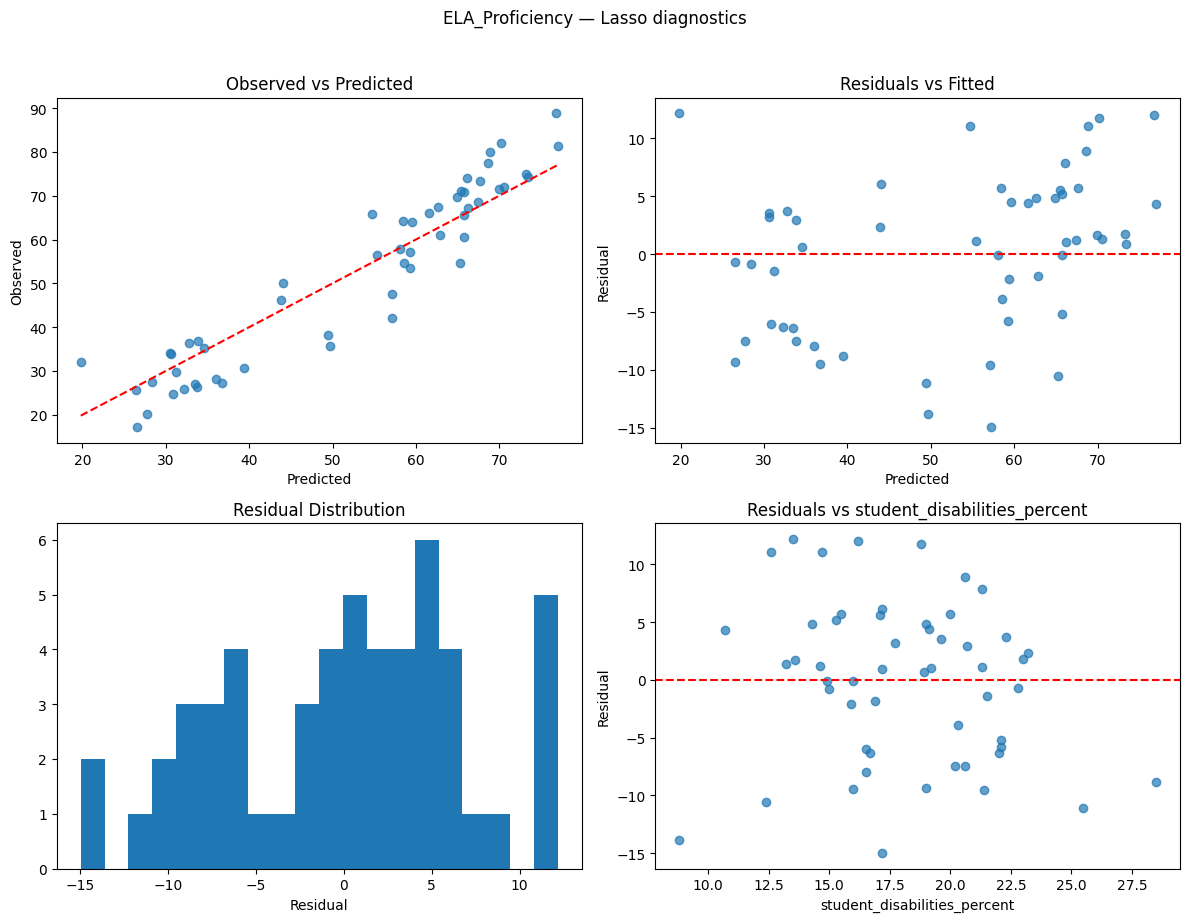

Lasso | ELA_Proficiency
N = 54
MAE = 5.606
RMSE = 6.834
Flagged potential outliers (|standardized residual| > 3): 0


In [74]:
plot_lasso_diagnostics(results["ELA_Proficiency"])

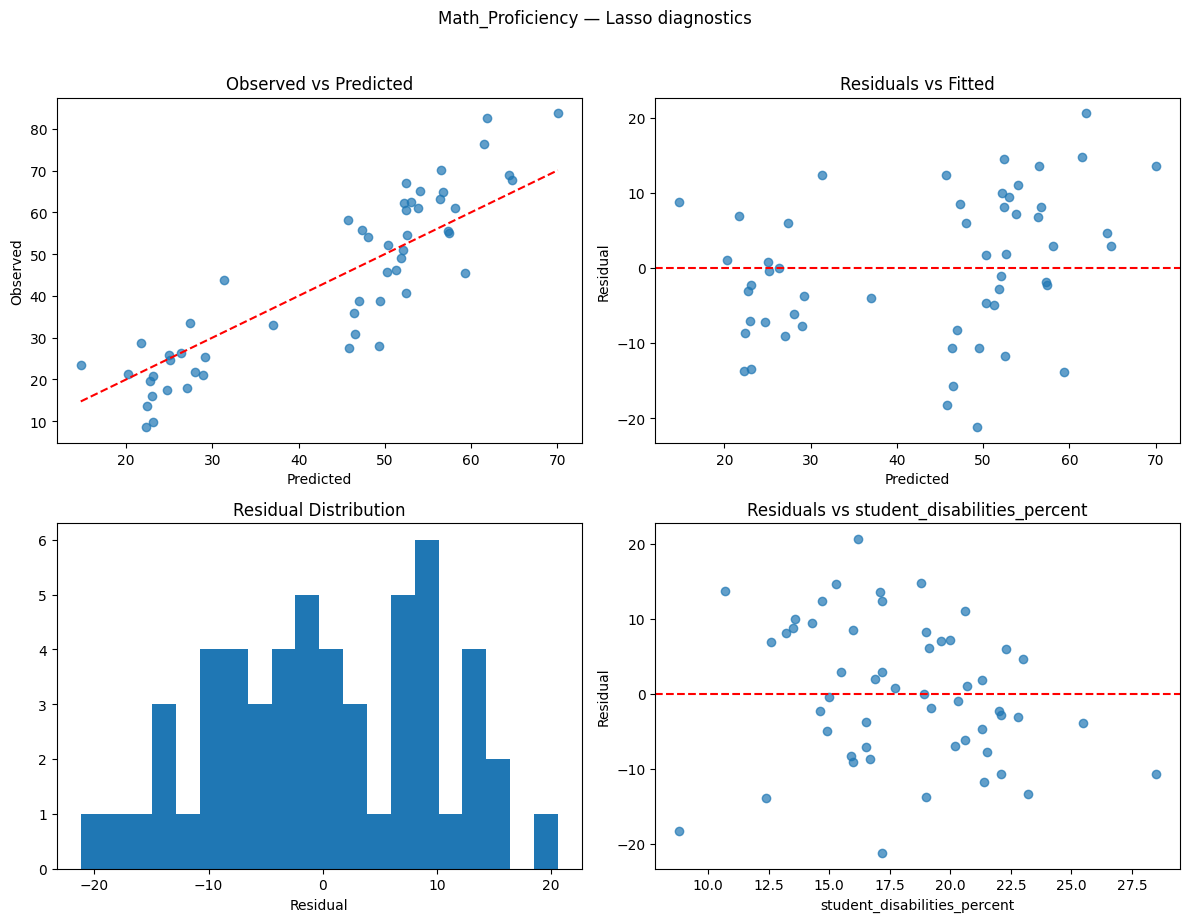

Lasso | Math_Proficiency
N = 54
MAE = 7.949
RMSE = 9.503
Flagged potential outliers (|standardized residual| > 3): 0


In [75]:
plot_lasso_diagnostics(results["Math_Proficiency"])

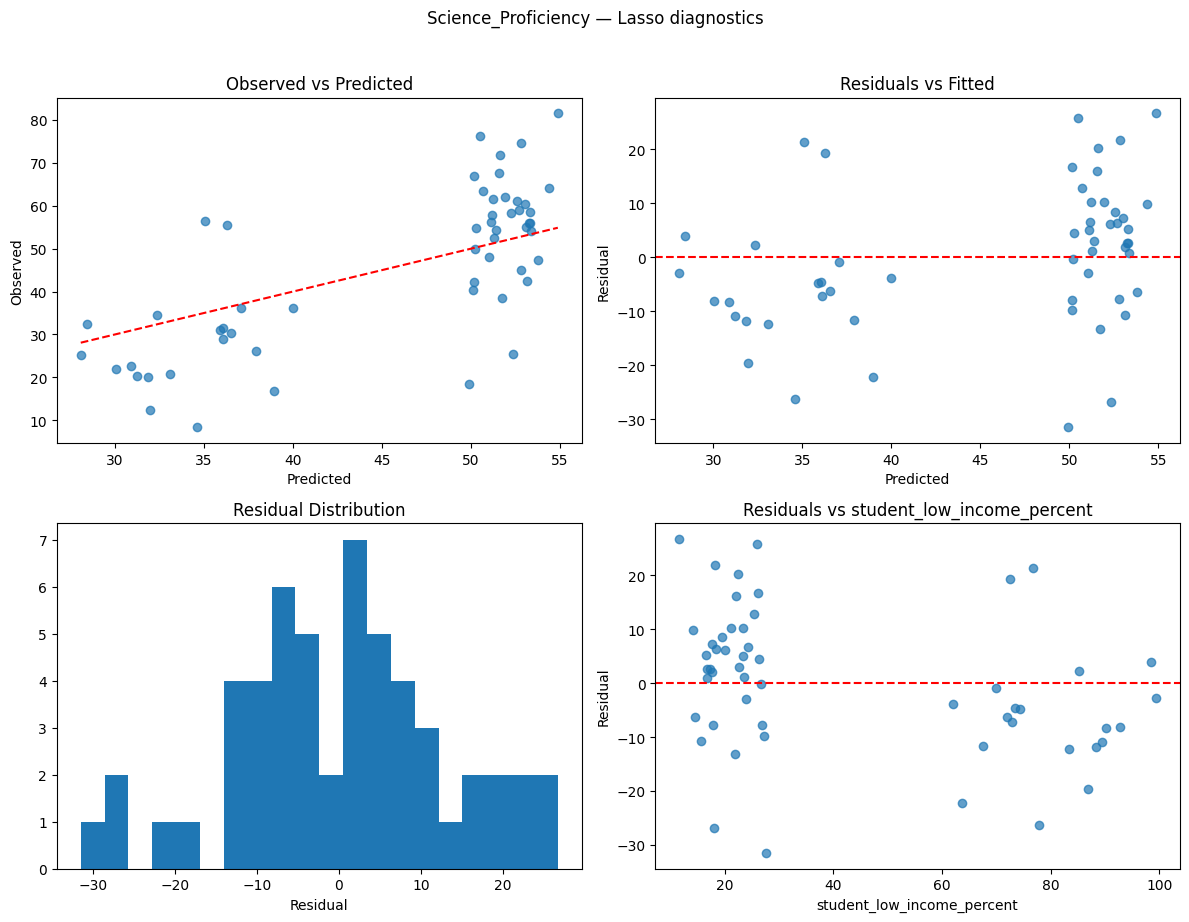

Lasso | Science_Proficiency
N = 54
MAE = 10.332
RMSE = 13.009
Flagged potential outliers (|standardized residual| > 3): 0


In [76]:
plot_lasso_diagnostics(results["Science_Proficiency"])

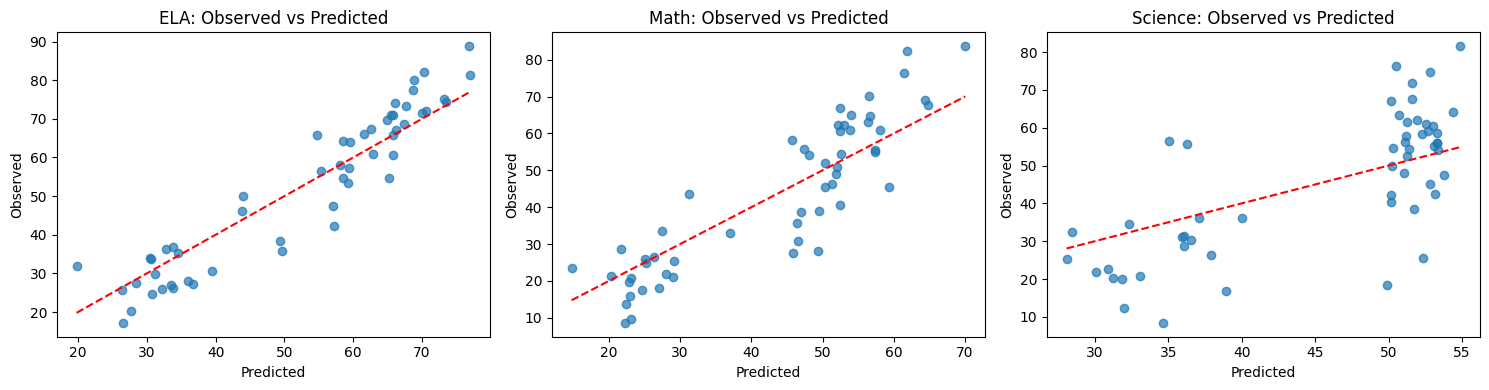

In [78]:
title_map = {
    "ELA_Proficiency": "ELA",
    "Math_Proficiency": "Math",
    "Science_Proficiency": "Science"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, outcome in zip(axes, OUTCOMES):
    res = results[outcome]
    y = res["y"]
    yhat = res["pipe"].predict(res["X"])

    ax.scatter(yhat, y, alpha=0.7)
    ax.plot([yhat.min(), yhat.max()], [yhat.min(), yhat.max()], "r--")
    ax.set_title(f"{title_map[outcome]}: Observed vs Predicted")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Observed")

plt.tight_layout()
plt.show()